# Flight Fare Prediction

### Problem Statement

##### The objective of this project is to predict airline ticket prices based on features such as airline, journey date, source, destination, stops, and duration using Machine Learning techniques.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Flight_Fare.xlsx")

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.shape

(10683, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [7]:
info_table = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes,
    "Missing Values": df.isnull().sum().values
})

info_table

,Column,Datatype,Missing Values
Airline,Airline,object,0
Date_of_Journey,Date_of_Journey,object,0
Source,Source,object,0
Destination,Destination,object,0
Route,Route,object,1
Dep_Time,Dep_Time,object,0
Arrival_Time,Arrival_Time,object,0
Duration,Duration,object,0
Total_Stops,Total_Stops,object,1
Additional_Info,Additional_Info,object,0


# Exploratory Data Analysis
### check the null values

In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

## Handle a missing values
#### Here we came to know that their is a Null Values but very less number of Null Values so we can drop the Null Values.
#### Route
#### Total_Stops

In [9]:
df.dropna(inplace = True)

##### Rows with missing values were removed because they represented a very small percentage of the dataset and would not significantly affect model performance.

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(220)

In [12]:
numeric_features=[feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features=[feature for feature in df.columns if df[feature].dtype == 'O']

#print columns
print(f'We have {len(numeric_features)} numerical features :{numeric_features}')
print(f'We have {len(categorical_features)} categorical features :{categorical_features}')  

We have 1 numerical features :['Price']
We have 10 categorical features :['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info']


#  FEATURE ENGINEERING 

## extracting Date & Month from Date of journey Column 
### Converting into Datetime:
##### We are going to extract the date and month from the date of the journey.
##### For this, we require pandas to _datetime to convert the object data type to DataTime data type.
##### .dt.day the method will extract only the day from the date.
##### .dt.month the method will extract only the month of that date.

In [13]:
df["journey_Date"] = pd.to_datetime(df["Date_of_Journey"], format = "%d/%m/%Y").dt.day

In [14]:
df["journey_Month"] = pd.to_datetime(df["Date_of_Journey"], format = "%d/%m/%Y").dt.month

In [15]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_Date,journey_Month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


###  Since we have extracted Date of Journey column into Date & Month, Now we can drop it as Original Date of Journey column is of no use.

In [16]:
df.drop(["Date_of_Journey"],axis=1,inplace=True)

#### Similar to Date of Journey we can extract values from Departure Time
#### so we will bw extracting Hur & Minutes from Departure Time Column

In [17]:
# Convert by explicitly defining the time format
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.hour
df["Dep_min"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.minute

In [18]:
df.drop(["Dep_Time"],axis=1, inplace=True)

In [19]:
# 1. Extract just the time part (HH:MM) by splitting the text and taking the first part
arrival_time_clean = df["Arrival_Time"].str.split().str[0]

# 2. Convert and extract hours and minutes safely
df["Arr_hour"] = pd.to_datetime(arrival_time_clean, format="%H:%M").dt.hour
df["Arr_min"] = pd.to_datetime(arrival_time_clean, format="%H:%M").dt.minute

In [20]:
df.drop(["Arrival_Time"], axis=1, inplace=True)

In [21]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,journey_Date,journey_Month,Dep_hour,Dep_min,Arr_hour,Arr_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [22]:
# Assigning and converting Duration column into list to extract hours ans minutes seperately
duration = list(df["Duration"])
for i in range(len(duration)):
    if len(duration[i].split()) !=2:  # Check if duration contains only hour or mins
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   # Adds 0 minute
        else:
            duration[i] = "0h " + duration[i]           # Adds 0 hour

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))    # Extract hours from duration
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))   # Extracts only minutes from duration

In [23]:
df["Duration_hours"] = duration_hours
df["Duration_mins"] = duration_mins

#we will remove the Durtaion column
df.drop(['Duration'],axis=1,inplace=True)

# EDA(Exploratory Data Analysis)
#### Data visulization


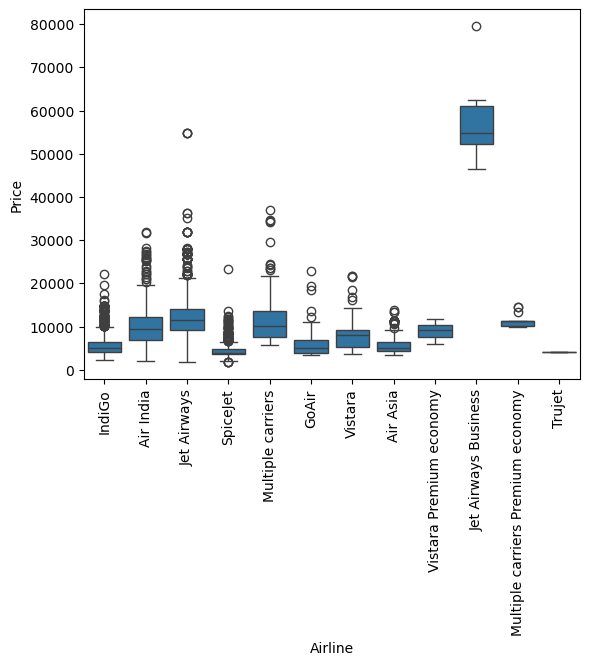

In [24]:
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=90)
plt.show()

#### From the abovve we can see that Jet Airways Business has premium flight fares as compared to other Airlines.

<Axes: xlabel='Total_Stops', ylabel='Price'>

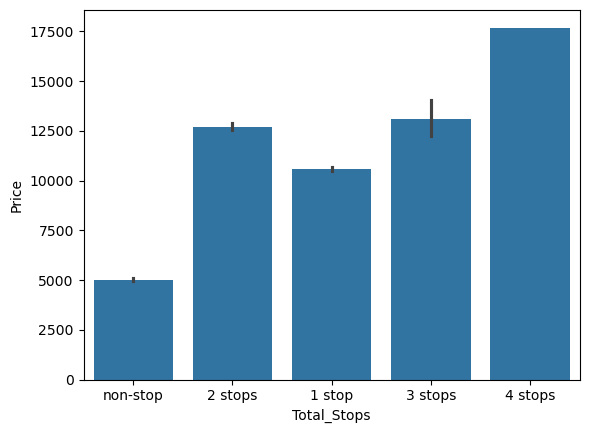

In [25]:
# Total Stops vs Price
sns.barplot(x="Total_Stops", y="Price", data=df)

#### Fights with more stops usually have higher prices.

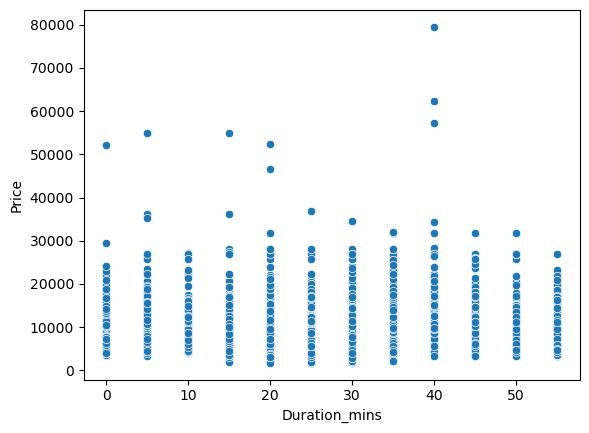

In [26]:
# Duration vs Price
sns.scatterplot(x="Duration_mins", y="Price", data=df)
plt.show()

#### Flight with more duration time useally have a higher price of tickets.

# Handling Categorical Data:
##### Airline, Source, Destination, Route, Total_Stops, Additional_info are the categorical variables we have in our data.
##### Nominal data -> are not in any order -> OneHotEncoder is used in this case.
##### Ordinal data -> are in order -> LabelEncoder is used in this case.

In [27]:
# For Airline
Airline = pd.get_dummies(df["Airline"], drop_first=False, dtype=int)

# For Source
Source = pd.get_dummies(df['Source'], drop_first=True, dtype=int)

# For Destination
Destination = pd.get_dummies(df['Destination'], drop_first=True, dtype=int)

In [28]:
Airline.head()

,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,0,0,0,1,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0


In [29]:
Source.head()

,Chennai,Delhi,Kolkata,Mumbai
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,0,1,0
4,0,0,0,0


In [30]:
Destination.head()

,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,0,0,0,1
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1


In [31]:
# droping column, because Additional_info has since 80% has no information
# Route ---> is related to no of stops
df.drop(['Route','Additional_Info'], axis=1, inplace=True)

In [32]:
df.head()

,Airline,Source,Destination,Total_Stops,Price,journey_Date,journey_Month,Dep_hour,Dep_min,Arr_hour,Arr_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,non-stop,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2 stops,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2 stops,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1 stop,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1 stop,13302,1,3,16,50,21,35,4,45


##### Total_stops variable:
##### Non-stop refer to a flight with no stops, i.e. a straight flight. It is self-evident that other values have the same meaning. We can see that it's Ordinal Data, thus we'll use LabelEncoder to deal with it.

In [33]:
df['Total_Stops'].value_counts()
# as this is case of ordinal categorical type we perform LabelEncoder
# we replace the values in key values
df.replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3, '4 stops':4}, inplace=True)
df.head()

C:\Users\abhi\AppData\Local\Temp\ipykernel_17528\1460609977.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3, '4 stops':4}, inplace=True)


,Airline,Source,Destination,Total_Stops,Price,journey_Date,journey_Month,Dep_hour,Dep_min,Arr_hour,Arr_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,35,4,45


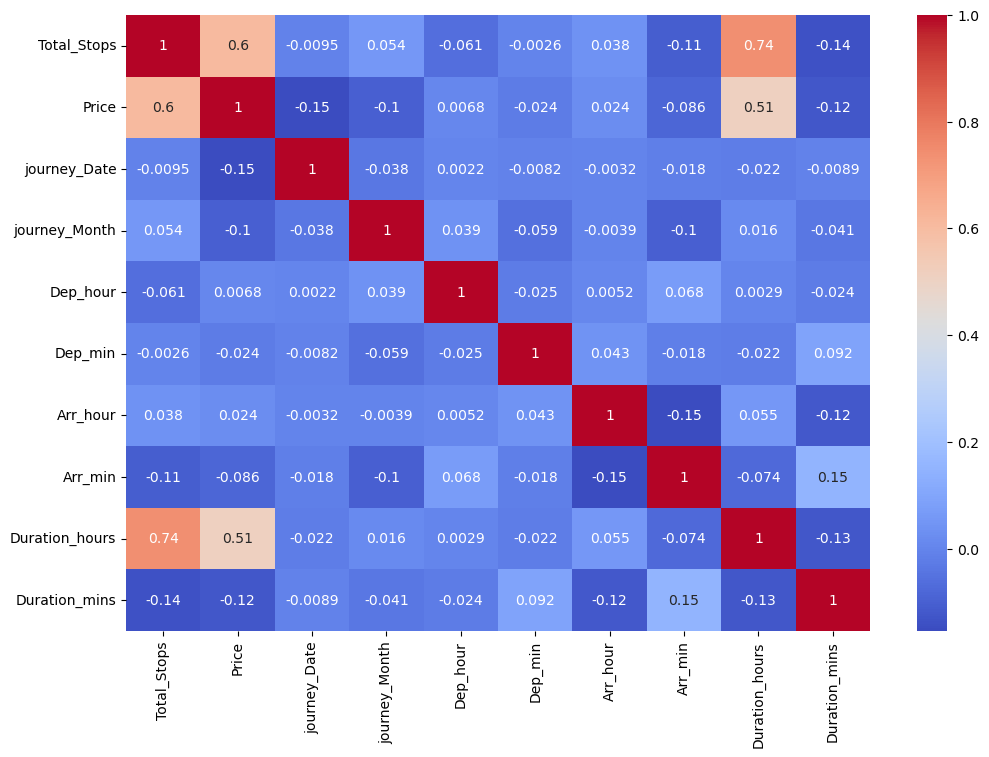

In [34]:
plt.figure(figsize=(12, 8))
# Added numeric_only=True inside df.corr()
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True) 
plt.show()

In [35]:
df.corr(numeric_only=True)

,Total_Stops,Price,journey_Date,journey_Month,Dep_hour,Dep_min,Arr_hour,Arr_min,Duration_hours,Duration_mins
Total_Stops,1.000000,0.603897,-0.009451,0.054383,-0.061476,-0.002618,0.038140,-0.106940,0.739916,-0.136706
Price,0.603897,1.000000,-0.153774,-0.103643,0.006799,-0.024458,0.024244,-0.086155,0.508778,-0.124855
journey_Date,-0.009451,-0.153774,1.000000,-0.038359,0.002170,-0.008170,-0.003245,-0.017510,-0.022059,-0.008940
journey_Month,0.054383,-0.103643,-0.038359,1.000000,0.039127,-0.059267,-0.003927,-0.100626,0.016141,-0.040897
Dep_hour,-0.061476,0.006799,0.002170,0.039127,1.000000,-0.024745,0.005180,0.067911,0.002869,-0.023707
Dep_min,-0.002618,-0.024458,-0.008170,-0.059267,-0.024745,1.000000,0.043122,-0.017597,-0.022104,0.092485
Arr_hour,0.038140,0.024244,-0.003245,-0.003927,0.005180,0.043122,1.000000,-0.154363,0.055276,-0.118309
Arr_min,-0.106940,-0.086155,-0.017510,-0.100626,0.067911,-0.017597,-0.154363,1.000000,-0.074450,0.151628
Duration_hours,0.739916,0.508778,-0.022059,0.016141,0.002869,-0.022104,0.055276,-0.074450,1.000000,-0.126468
Duration_mins,-0.136706,-0.124855,-0.008940,-0.040897,-0.023707,0.092485,-0.118309,0.151628,-0.126468,1.000000


In [36]:
# 1. Correctly concatenate using pd.concat and your active variable 'df'
df_train = pd.concat([df, Airline, Source, Destination], axis=1)

# 2. Drop the original string columns
df_train.drop(['Airline', 'Source', 'Destination'], axis=1, inplace=True)
df_train.head()

,Total_Stops,Price,journey_Date,journey_Month,Dep_hour,Dep_min,Arr_hour,Arr_min,Duration_hours,Duration_mins,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,5,50,13,15,7,25,...,0,0,0,1,0,0,0,0,0,0
2,2,13882,9,6,9,25,4,25,19,0,...,0,0,1,0,0,1,0,0,0,0
3,1,6218,12,5,18,5,23,30,5,25,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,1,3,16,50,21,35,4,45,...,0,0,0,0,0,0,0,0,0,1


##### As a result, the final dataframe has 30 variables, including the depentdent variable 'price' for training, there are only 29 variables.
##### Test Data:
##### We are going to repeat all these steps for test data as well.
##### Importing test data

In [37]:
# 1. Freshly reload the data so all original columns are present every time you run this cell
test_data = pd.read_excel("Flight_Fare.xlsx")
test_data.dropna(inplace=True)

print(test_data.info())
print(test_data.isnull().sum())

# ==================== EDA & FEATURE ENGINEERING ====================

# Date_of_Journey
test_data["Journey_day"] = pd.to_datetime(test_data["Date_of_Journey"], format="%d/%m/%Y").dt.day
test_data["Journey_month"] = pd.to_datetime(test_data["Date_of_Journey"], format="%d/%m/%Y").dt.month
test_data.drop(["Date_of_Journey"], axis=1, inplace=True)

# Dep_Time
test_data["Dep_hour"] = pd.to_datetime(test_data["Dep_Time"]).dt.hour
test_data["Dep_min"] = pd.to_datetime(test_data["Dep_Time"]).dt.minute
test_data.drop(["Dep_Time"], axis=1, inplace=True)

# Arrival_Time
test_data["Arrival_hour"] = pd.to_datetime(test_data["Arrival_Time"]).dt.hour
test_data["Arrival_min"] = pd.to_datetime(test_data["Arrival_Time"]).dt.minute
test_data.drop(["Arrival_Time"], axis=1, inplace=True)

# Duration
duration = list(test_data["Duration"])
for i in range(len(duration)):
    if len(duration[i].split()) != 2:    # Check if duration contains only hour or mins
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   # Adds 0 minute
        else:
            duration[i] = "0h " + duration[i]           # Adds 0 hour

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))    # Extract hours from duration
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))   # Extracts only minutes from duration

# Adding Duration columns to test set
test_data["Duration_hours"] = duration_hours
test_data["Duration_mins"] = duration_mins
test_data.drop(["Duration"], axis=1, inplace=True)


# ==================== CATEGORICAL DATA (NOMINAL) ====================

print("Airline")
print("-" * 75)
print(test_data["Airline"].value_counts())
# Added dtype=int to prevent True/False boolean outputs
Airline = pd.get_dummies(test_data["Airline"], drop_first=True, dtype=int)

print(test_data["Source"].value_counts())
Source = pd.get_dummies(test_data["Source"], drop_first=True, dtype=int)

print(test_data["Destination"].value_counts())
Destination = pd.get_dummies(test_data["Destination"], drop_first=True, dtype=int)

# Drop redundant or unhelpful columns
test_data.drop(["Route", "Additional_Info"], axis=1, inplace=True)

# Replacing Total_Stops ordinal values with integers
test_data.replace({"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}, inplace=True)


# ==================== CONCATENATION ====================

# Concatenate dataframe --> test_data + Airline + Source + Destination
data_test = pd.concat([test_data, Airline, Source, Destination], axis=1)

# Drop original categorical text columns
data_test.drop(["Airline", "Source", "Destination"], axis=1, inplace=True)

print()
print()
print("Shape of test data : ", data_test.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 1001.4+ KB
None
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64
Airline


C:\Users\abhi\AppData\Local\Temp\ipykernel_17528\4005351853.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_data["Dep_hour"] = pd.to_datetime(test_data["Dep_Time"]).dt.hour
C:\Users\abhi\AppData\Local\Temp\ipykernel_17528\4005351853.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_data["Dep_min"] = pd.to_datetime(test_data["Dep_Time"]).dt.minute
C:\Users\abhi\AppData\Local\Temp\ipykernel_17528\4005351853.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_data["Arrival_hour"] = pd.to_datetime(test_data["Arrival_Time"]).dt.hour
C:\Users\abhi\AppData\

In [38]:
data_test.shape

(10682, 30)

## Now we will Build a Machine Learning Model Using Random Forest Algorithm

In [39]:
df_train.columns

Index(['Total_Stops', 'Price', 'journey_Date', 'journey_Month', 'Dep_hour',
       'Dep_min', 'Arr_hour', 'Arr_min', 'Duration_hours', 'Duration_mins',
       'Air Asia', 'Air India', 'GoAir', 'IndiGo', 'Jet Airways',
       'Jet Airways Business', 'Multiple carriers',
       'Multiple carriers Premium economy', 'SpiceJet', 'Trujet', 'Vistara',
       'Vistara Premium economy', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai',
       'Cochin', 'Delhi', 'Hyderabad', 'Kolkata', 'New Delhi'],
      dtype='object')

In [40]:
# Separate the independent variables (X) and dependent variable (y)
X = df_train.drop(["Price"], axis=1)
y = df_train["Price"]

# View the features to confirm they are correct
X.head()

,Total_Stops,journey_Date,journey_Month,Dep_hour,Dep_min,Arr_hour,Arr_min,Duration_hours,Duration_mins,Air Asia,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,24,3,22,20,1,10,2,50,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1,5,5,50,13,15,7,25,0,...,0,0,0,1,0,0,0,0,0,0
2,2,9,6,9,25,4,25,19,0,0,...,0,0,1,0,0,1,0,0,0,0
3,1,12,5,18,5,23,30,5,25,0,...,0,0,0,1,0,0,0,0,0,0
4,1,1,3,16,50,21,35,4,45,0,...,0,0,0,0,0,0,0,0,0,1


## Feature importance

In [41]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor()

model.fit(X, y)

ExtraTreesRegressor()

In [42]:
print(model.feature_importances_)

[2.28555661e-01 1.45619249e-01 5.23760242e-02 2.35418149e-02
 2.09372746e-02 2.81583897e-02 1.86659851e-02 1.26995189e-01
 1.77191588e-02 2.36946600e-03 8.38475281e-03 2.03553468e-03
 1.80593181e-02 1.35766789e-01 6.70937403e-02 1.72282971e-02
 7.68919298e-04 3.36550658e-03 1.25665757e-04 4.65138528e-03
 8.61547000e-05 4.63320117e-04 1.11341380e-02 3.13456206e-03
 6.79244808e-03 1.04753637e-02 1.29878167e-02 7.06174423e-03
 5.09099917e-04 2.49372310e-02]


<Axes: >

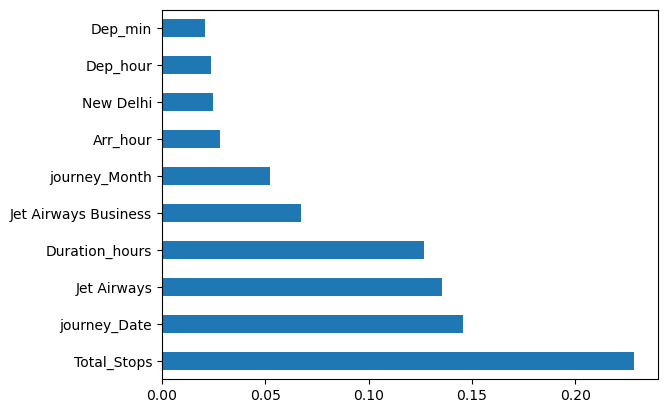

In [43]:
feat_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feat_importance.nlargest(10).plot(kind='barh')

In [44]:
# Splitting the data into Train & Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=32)

In [45]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate the model
random_forest = RandomForestRegressor()

In [46]:
random_forest.fit(X_train,y_train)

RandomForestRegressor()

In [47]:
random_forest.score(X_test,y_test)

0.8184653466598213

In [48]:
random_forest.score(X_train,y_train)

0.9557357640040719

In [49]:
y_prediction = random_forest.predict(X_test)

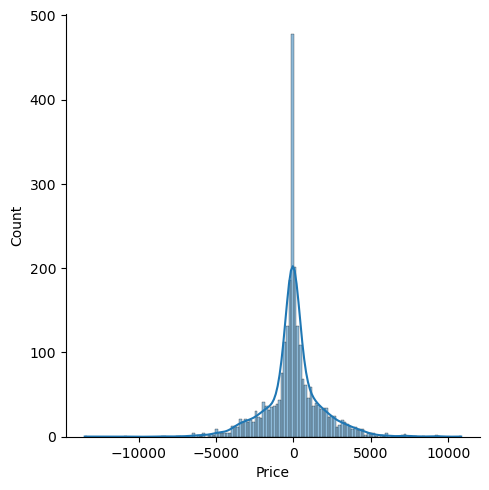

In [50]:
# plotting the error graph and should be mean = 0
sns.displot(y_test-y_prediction,kde=True)

##### with an R2 score of 81 percent, with this model, we can also calculate the minimal values for mean alsolute error, mean squared error, we will try to improve the accuracy by doing hyperparameter tunning.

In [51]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_prediction))
print('MSE:', metrics.mean_squared_error(y_test, y_prediction))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_prediction)))

MAE: 1176.1666565516414
MSE: 3410470.5909276353
RMSE: 1846.7459465036427


Text(0, 0.5, 'prediction')

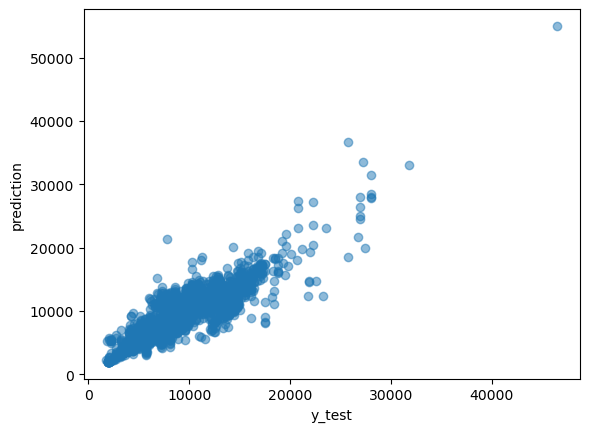

In [52]:
# plotting scatter graph to check linear relations
plt.scatter(y_test,y_prediction,alpha=0.5)
plt.xlabel('y_test')
plt.ylabel('prediction')

##### Here we will be using RandomizedSearchCV

In [53]:
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(5, 30, num = 8)]
min_samples_split = [2, 5, 10, 15, 100, 120, 150, 200, 250]
min_samples_leaf = [1, 2, 5, 10,15,25,30,35]

In [54]:
andom_grid_params = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

In [55]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split

#### We will pass these parameter into our random forest classifier.

In [56]:
# 'auto' is replaced with None to use all features
random_forest_regresor = RandomForestRegressor(
    n_estimators=300, 
    min_samples_split=10, 
    min_samples_leaf=2, 
    max_features=None, 
    max_depth=15
)

In [57]:
random_forest_regresor.fit(X_train,y_train)

RandomForestRegressor(max_depth=15, max_features=None, min_samples_leaf=2,
                      min_samples_split=10, n_estimators=300)

In [58]:
random_forest_regresor.score(X_train,y_train)

0.8978080442202929

In [59]:
# R2 score

random_forest_regresor.score(X_test,y_test)

0.8441417485404279

In [60]:
prediction=random_forest_regresor.predict(X_test)

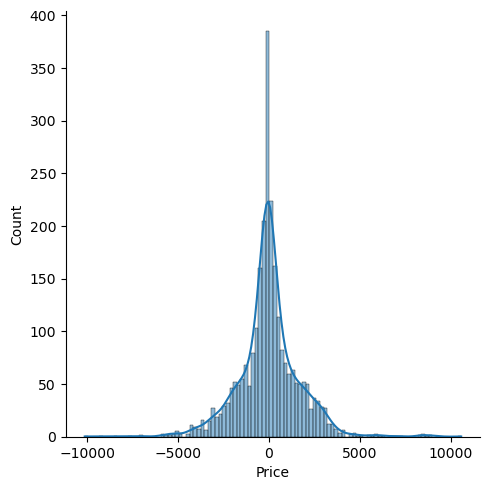

In [61]:
sns.displot(y_test-prediction,kde=True)

Text(0, 0.5, 'prediction')

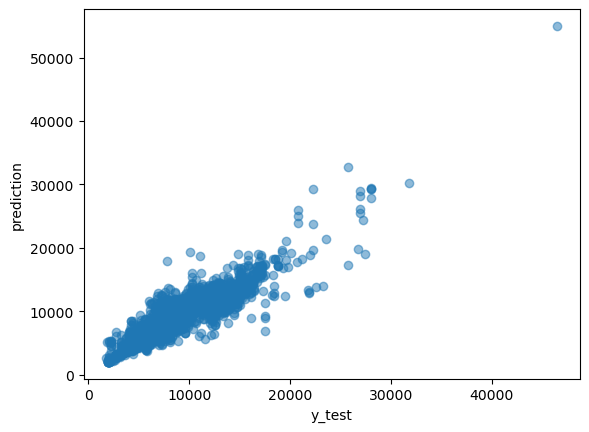

In [62]:
#Plotting scatter graph to check linear relations
plt.scatter(y_test,prediction,alpha=0.5)
plt.xlabel('y_test')
plt.ylabel('prediction')

In [63]:
print('MAE:', metrics.mean_absolute_error(y_test, prediction))
print('MSE:', metrics.mean_squared_error(y_test, prediction))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, prediction)))

MAE: 1143.6555387409549
MSE: 2928090.9907608684
RMSE: 1711.1665584509499


In [64]:
X_test

,Total_Stops,journey_Date,journey_Month,Dep_hour,Dep_min,Arr_hour,Arr_min,Duration_hours,Duration_mins,Air Asia,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
8396,2,24,6,18,20,4,25,10,5,0,...,0,0,1,0,0,1,0,0,0,0
9284,1,9,6,17,30,12,35,19,5,0,...,0,0,1,0,0,1,0,0,0,0
10609,0,12,5,12,0,13,30,1,30,0,...,0,0,0,0,1,0,0,1,0,0
10229,0,3,3,19,35,22,5,2,30,1,...,0,0,0,1,0,0,0,0,0,0
3874,1,27,3,2,15,15,30,13,15,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5803,0,24,3,23,30,2,20,2,50,0,...,0,0,0,0,0,0,0,0,0,1
5663,1,6,5,11,35,18,50,7,15,0,...,0,0,0,1,0,0,0,0,0,0
8332,0,27,6,11,30,14,5,2,35,0,...,0,0,0,1,0,0,0,0,0,0
10453,2,24,6,9,40,12,35,26,55,0,...,0,0,1,0,0,1,0,0,0,0


In [65]:
y_prediction = model.predict(X_test)

In [66]:
print(y_prediction)

[13775.  10262.   2754.  ...  4804.  11691.   7622.5]


In [67]:
comparision = pd.DataFrame({"Actual": y_test, "predicted": y_prediction})
comparision.head()

,Actual,predicted
8396,13775,13775.0
9284,10262,10262.0
10609,2754,2754.0
10229,5964,5964.0
3874,12327,12327.0


In [68]:
model.predict(X_test.iloc[0:1])

array([13775.])

In [69]:
print("Actual:", y_test.iloc[0])

print("Predicted:", model.predict(X_test.iloc[0:1])[0])

Actual: 13775
Predicted: 13775.0


In [70]:
print(X.shape)

(10682, 30)


In [71]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print(prediction)

[13775.]


In [72]:
print("Actual:", y_test.iloc[0])

print("Predicted:", prediction[0])

Actual: 13775
Predicted: 13775.0


# Linear Regression model
#### It helps compare performance with advanced models like Random Forest.

In [73]:
from sklearn.linear_model import LinearRegression

In [74]:
# Model training
lr_model = LinearRegression()
lr_model.fit(X_train,y_train) # This teaches the model

LinearRegression()

In [75]:
# Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error
y_prediction = lr_model.predict(X_test)

In [76]:
print("R2 score: ", r2_score(y_test, y_prediction))

R2 score:  0.6246491102288823


In [77]:
print("MAE:", mean_absolute_error(y_test, y_prediction))

MAE: 1939.3265246996027


# Decision Tree
#### Good for model comparision.

In [78]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [79]:
# create a model
model= DecisionTreeRegressor()

In [80]:
#Train model
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [81]:
#model prediction
y_prediction = model.predict(X_test)

In [82]:
#Accuracy
r2_score(y_test, y_prediction)

0.6990617448115446

In [83]:
mean_absolute_error(y_test, y_prediction)

1367.5768875577187

In [84]:
## Comparision of all Regression
import matplotlib.pyplot as plt

In [85]:
models = ["Linear Regression", "Decision Tree", "Random Forest"]
scores = [0.62, 0.69, 0.81]

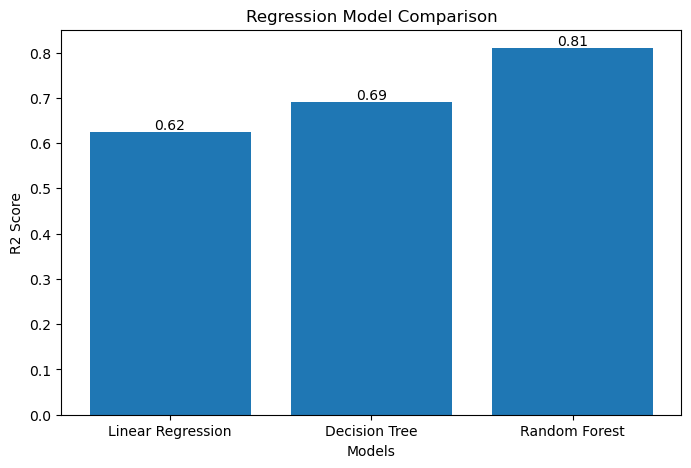

In [86]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Decision Tree', 'Random Forest']

scores = [0.6246, 0.69, 0.81]

plt.figure(figsize=(8,5))

bars = plt.bar(models, scores)

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.title("Regression Model Comparison")

for bar in bars:
    
    yval = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval,2),
        ha='center',
        va='bottom'
    )

plt.show()

In [87]:
comparison_table = pd.DataFrame({ 
    "Model": ["Linear Regression","Decision Tree","Random Forest"],

    "R2 Score": [ 0.62, 0.69,0.81],

    "MAE": [1939,1364,1182 ]})

comparison_table

,Model,R2 Score,MAE
0,Linear Regression,0.62,1939
1,Decision Tree,0.69,1364
2,Random Forest,0.81,1182


#### The Random Forest model achieved the highest R² score, indicating strong predictive performance on unseen data.

# Challenges Faced During the Project

During the development of the Flight Fare Prediction project, several challenges were encountered related to preprocessing, feature engineering, and model optimization.

| Challenge Faced                                                        | Solution Used                         | Reason                                                                   |
| ---------------------------------------------------------------------- | ------------------------------------- | ------------------------------------------------------------------------ |
| Missing values in Route and Total_Stops columns                        | Used `dropna()`                       | Missing rows were very few and did not significantly affect the dataset  |
| Duration column contained text values like `2h 50m`                    | Converted duration into total minutes | Machine learning models work better with numerical data                  |
| Categorical columns like Airline and Source could not be directly used | Applied One-Hot Encoding              | ML algorithms cannot understand text values directly                     |
| Extracting useful information from date and time columns               | Used `pd.to_datetime()`               | Helped create meaningful features such as journey day and departure hour |
| Choosing the best model for prediction                                 | Compared multiple regression models   | Helped identify the best-performing model                                |
| Hyperparameter tuning was complex                                      | Used `RandomizedSearchCV`             | Improved model performance automatically                                 |


# Conclusion

The Flight Fare Prediction project was successfully completed using machine learning techniques. Different preprocessing and feature engineering methods were applied to prepare the data for model training. Multiple regression models were evaluated, and Random Forest Regressor achieved the best performance.

The project shows that flight prices can be predicted effectively using factors such as airline, duration, source, destination, and total stops. This system can help customers estimate ticket prices and plan their journeys more efficiently.

This system can help customers estimate flight prices and help airlines understand pricing trends.


In [88]:
%%writefile app.py

import streamlit as st
import pickle

model = pickle.load(open("model.pkl", "rb"))

st.title("Flight Fare Prediction")

Overwriting app.py


In [90]:
import pickle

# Changed rf_model to random_forest
pickle.dump(random_forest, open("model.pkl", "wb"))

In [91]:
import pickle

pickle.dump(X.columns, open("columns.pkl", "wb"))

In [92]:
import pickle
import pandas as pd

model = pickle.load(open("model.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

In [103]:
input_dict = {
    "Airline": Airline,
    "Source": Source,
    "Destination": Destination,
    "Total_Stops": Stops
    
}

NameError: name 'Stops' is not defined